Imports

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

Load data and preview

In [ ]:
df = pd.read_csv('/Users/kaungkhantkyaw/Documents/GitHub/Analyse-US-Domestic-flights/Data/Raw/Origin_and_Destination_Survey_DB1BMarket_2025_1.csv')
display(df.head())
print(df.shape)

,ItinID,MktID,MktCoupons,Year,Quarter,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCountry,...,BulkFare,Passengers,MktFare,MktDistance,MktDistanceGroup,MktMilesFlown,NonStopMiles,ItinGeoType,MktGeoType,Unnamed: 41
0,202511660219,20251166021902,1,2025,1,14679,1467903,33570,SAN,US,...,0.0,1.0,351.5,1892.0,4,1892.0,1892.0,2,2,NaN
1,202511660220,20251166022001,1,2025,1,10397,1039707,30397,ATL,US,...,0.0,2.0,352.0,1892.0,4,1892.0,1892.0,2,2,NaN
2,202511660220,20251166022002,1,2025,1,14679,1467903,33570,SAN,US,...,0.0,2.0,352.0,1892.0,4,1892.0,1892.0,2,2,NaN
3,202511660221,20251166022101,1,2025,1,10397,1039707,30397,ATL,US,...,0.0,1.0,352.5,1892.0,4,1892.0,1892.0,2,2,NaN
4,202511660221,20251166022102,1,2025,1,14679,1467903,33570,SAN,US,...,0.0,1.0,352.5,1892.0,4,1892.0,1892.0,2,2,NaN


(7297028, 42)


Data Understanding

In [27]:
display(df.info())
display(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 7297028 entries, 0 to 7297027
Data columns (total 42 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ItinID              int64  
 1   MktID               int64  
 2   MktCoupons          int64  
 3   Year                int64  
 4   Quarter             int64  
 5   OriginAirportID     int64  
 6   OriginAirportSeqID  int64  
 7   OriginCityMarketID  int64  
 8   Origin              str    
 9   OriginCountry       str    
 10  OriginStateFips     int64  
 11  OriginState         str    
 12  OriginStateName     str    
 13  OriginWac           int64  
 14  DestAirportID       int64  
 15  DestAirportSeqID    int64  
 16  DestCityMarketID    int64  
 17  Dest                str    
 18  DestCountry         str    
 19  DestStateFips       int64  
 20  DestState           str    
 21  DestStateName       str    
 22  DestWac             int64  
 23  AirportGroup        str    
 24  WacGroup            str    
 25  Tk

None

,ItinID,MktID,MktCoupons,Year,Quarter,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginStateFips,OriginWac,...,BulkFare,Passengers,MktFare,MktDistance,MktDistanceGroup,MktMilesFlown,NonStopMiles,ItinGeoType,MktGeoType,Unnamed: 41
count,7.297028e+06,7.297028e+06,7.297028e+06,7297028.0,7297028.0,7.297028e+06,7.297028e+06,7.297028e+06,7.297028e+06,7.297028e+06,...,7.297028e+06,7.297028e+06,7.297028e+06,7.297028e+06,7.297028e+06,7.297028e+06,7.297028e+06,7.297028e+06,7.297028e+06,0.0
mean,1.761292e+11,1.761292e+13,1.443969e+00,2025.0,1.0,1.286037e+04,1.286040e+06,3.200068e+04,2.679798e+01,5.440520e+01,...,7.030259e-05,1.885363e+00,2.768339e+02,1.304922e+03,3.109719e+00,1.302205e+03,1.226398e+03,1.925249e+00,1.925391e+00,NaN
std,6.468585e+10,6.468585e+12,5.438571e-01,0.0,0.0,1.533206e+03,1.533205e+05,1.381797e+03,1.718727e+01,2.726579e+01,...,8.384370e-03,4.856354e+00,2.328516e+02,8.196959e+02,1.669155e+00,8.184331e+02,7.767147e+02,2.629887e-01,2.627592e-01,NaN
min,2.025150e+07,2.025151e+09,1.000000e+00,2025.0,1.0,1.013500e+04,1.013506e+06,3.000900e+04,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,3.100000e+01,1.000000e+00,0.000000e+00,3.100000e+01,1.000000e+00,1.000000e+00,NaN
25%,2.025117e+11,2.025117e+13,1.000000e+00,2025.0,1.0,1.129800e+04,1.129806e+06,3.079200e+04,1.200000e+01,3.300000e+01,...,0.000000e+00,1.000000e+00,1.495000e+02,7.270000e+02,2.000000e+00,7.250000e+02,6.670000e+02,2.000000e+00,2.000000e+00,NaN
50%,2.025132e+11,2.025132e+13,1.000000e+00,2025.0,1.0,1.295300e+04,1.295304e+06,3.170300e+04,2.500000e+01,5.100000e+01,...,0.000000e+00,1.000000e+00,2.340000e+02,1.091000e+03,3.000000e+00,1.089000e+03,1.029000e+03,2.000000e+00,2.000000e+00,NaN
75%,2.025147e+11,2.025147e+13,2.000000e+00,2025.0,1.0,1.410700e+04,1.410702e+06,3.310500e+04,4.200000e+01,8.200000e+01,...,0.000000e+00,1.000000e+00,3.480000e+02,1.739000e+03,4.000000e+00,1.737000e+03,1.624000e+03,2.000000e+00,2.000000e+00,NaN
max,2.025160e+11,2.025160e+13,8.000000e+00,2025.0,1.0,1.686900e+04,1.686902e+06,3.610100e+04,7.800000e+01,9.300000e+01,...,1.000000e+00,1.032000e+03,3.065600e+04,1.134400e+04,2.300000e+01,1.134400e+04,9.411000e+03,2.000000e+00,2.000000e+00,NaN


In [30]:
display(df.dtypes.value_counts())
display(df.isna().sum())

int64      18
str        15
float64     9
Name: count, dtype: int64

ItinID                      0
MktID                       0
MktCoupons                  0
Year                        0
Quarter                     0
OriginAirportID             0
OriginAirportSeqID          0
OriginCityMarketID          0
Origin                      0
OriginCountry               0
OriginStateFips             0
OriginState                 0
OriginStateName             0
OriginWac                   0
DestAirportID               0
DestAirportSeqID            0
DestCityMarketID            0
Dest                        0
DestCountry                 0
DestStateFips               0
DestState                   0
DestStateName               0
DestWac                     0
AirportGroup                0
WacGroup                    0
TkCarrierChange             0
TkCarrierGroup              0
OpCarrierChange             0
OpCarrierGroup              0
RPCarrier                   0
TkCarrier                   0
OpCarrier                   0
BulkFare                    0
Passengers

In [31]:
df.duplicated().sum()

np.int64(0)

In [ ]:
display(df[['OriginState', 'OriginStateName']].drop_duplicates().sort_values(by='OriginState'))
display(df[['OriginState', 'OriginStateName']].nunique()) #checking if the origin state and origin state name are the same

,OriginState,OriginStateName
3253,AK,Alaska
17599,AL,Alabama
17565,AR,Arkansas
2004,AZ,Arizona
0,CA,California
1924,CO,Colorado
14558,CT,Connecticut
410379,DE,Delaware
1920,FL,Florida
1,GA,Georgia


OriginState        53
OriginStateName    53
dtype: int64

In [ ]:
df.groupby('OriginState')[['OriginStateFips', 'OriginWac']].nunique().sort_values(['OriginStateFips', 'OriginWac'], ascending=False)
#this checks if the origin state fips and origin wac are the same and consistent with 1 state

,OriginStateFips,OriginWac
OriginState,,
AK,1,1
AL,1,1
AR,1,1
AZ,1,1
CA,1,1
CO,1,1
CT,1,1
DE,1,1
FL,1,1


In [ ]:
display(df['TkCarrierChange'].value_counts())
display(df['ItinGeoType'].value_counts())
display(df['MktGeoType'].value_counts())
#Checking the different value entries for these columns

TkCarrierChange
0.0    7185776
1.0     111252
Name: count, dtype: int64

ItinGeoType
2    6751570
1     545458
Name: count, dtype: int64

MktGeoType
2    6752605
1     544423
Name: count, dtype: int64

In [ ]:
display(df.groupby("MktGeoType")[["OriginState", "DestState"]].value_counts().head(30))
#checking the different states related to the market geo type of 1 and 2. This shows that 1 is most likely non-mainland US

MktGeoType  OriginState  DestState
1           HI           CA           40150
            CA           HI           38551
            HI           HI           17105
            PR           FL           11776
            HI           WA           11393
            FL           PR           11200
            WA           HI           11041
            AK           AK            8785
            HI           TX            8387
            TX           HI            8130
            HI           OR            6683
            PR           NY            6634
            OR           HI            6552
            NV           HI            6436
            HI           NV            6306
            NY           PR            6182
            PR           TX            5511
            HI           CO            5403
                         AZ            5353
            TX           PR            5291
            CO           HI            5262
            AZ           HI            51

In [52]:
df[df["MktGeoType"] == 1][["Origin", "OriginState", "Dest", "DestState"]].drop_duplicates().head(50)

,Origin,OriginState,Dest,DestState
668,ATL,GA,SJU,PR
669,SJU,PR,ATL,GA
676,ATL,GA,HNL,HI
677,HNL,HI,ATL,GA
780,ATL,GA,LIH,HI
781,LIH,HI,ATL,GA
3221,ATL,GA,ANC,AK
3252,ATL,GA,FAI,AK
3253,FAI,AK,ATL,GA
3269,ANC,AK,ATL,GA


In [ ]:
df[df["MktGeoType"] == 2][["Origin", "OriginState", "Dest", "DestState"]].drop_duplicates().head(50)
# this confirms that the market geo type of 2 is mainland US, these values will apply to ItinGeoType 1 and 2 too

,Origin,OriginState,Dest,DestState
0,SAN,CA,ATL,GA
1,ATL,GA,SAN,CA
649,ATL,GA,ECP,FL
652,ATL,GA,JAN,MS
655,ATL,GA,MCO,FL
658,ATL,GA,MIA,FL
661,ATL,GA,MSY,LA
662,MSY,LA,ATL,GA
665,ATL,GA,SAV,GA
675,SAN,CA,BNA,TN


In [ ]:
display(df['TkCarrier'].value_counts())
display(df['RPCarrier'].value_counts())
display(df['OpCarrier'].value_counts())
#checking the values of the different carrier columns for any similarities



TkCarrier
AA    1667888
WN    1478889
DL    1440933
UA    1283482
AS     366874
NK     230989
F9     222814
G4     170105
B6     169156
99     111252
HA      63961
MX      53146
XP      20401
SY      12974
3M       3088
--        809
LF        104
KG         49
PR         22
9K         19
9X         18
QR         17
QF         10
BA          5
VC          4
FJ          3
RJ          3
SQ          3
AD          2
TP          1
CX          1
IB          1
AM          1
AY          1
ET          1
AC          1
LA          1
Name: count, dtype: int64

RPCarrier
WN    1484292
DL    1088782
AA    1052476
UA     916221
OO     494443
AS     256448
NK     230989
YX     225208
F9     222814
MQ     195974
OH     173484
B6     172341
G4     170105
9E     161463
QX      70010
PT      69800
HA      67569
YV      58604
MX      53146
C5      37611
G7      35805
ZW      20797
XP      20401
SY      13178
3M       5067
Name: count, dtype: int64

OpCarrier
WN    1478889
99    1184639
DL     961186
AA     857528
UA     797726
OO     253082
NK     230989
AS     230436
F9     222814
G4     170105
B6     167500
YX     167326
MQ      96747
OH      88152
9E      83373
HA      63508
MX      53146
QX      47849
YV      38604
PT      21736
XP      20401
G7      20019
C5      16704
SY      12974
ZW       5977
3M       4564
--        809
LF        104
9K         68
KG         49
9X         18
VC          4
TP          1
ET          1
Name: count, dtype: int64

Dropping uneccessary columns

In [72]:
df = df.drop(columns=['OriginCountry', 'DestCountry', 'OriginAirportSeqID', 'DestAirportSeqID', 'OriginStateName',
 'DestStateName', 'OriginStateFips', 'OriginWac', 'DestStateFips', 'DestWac', 'WacGroup', 'Unnamed: 41', 'AirportGroup', 'ItinGeoType', 'OriginAirportID', 
 'DestAirportID', 'OpCarrierGroup', 'TkCarrierGroup'], errors='ignore') #dropping as this analysis is only for US domestic flights
print(df.columns)



Index(['ItinID', 'MktID', 'MktCoupons', 'Year', 'Quarter',
       'OriginCityMarketID', 'Origin', 'OriginState', 'DestCityMarketID',
       'Dest', 'DestState', 'TkCarrierChange', 'OpCarrierChange', 'RPCarrier',
       'TkCarrier', 'OpCarrier', 'BulkFare', 'Passengers', 'MktFare',
       'MktDistance', 'MktDistanceGroup', 'MktMilesFlown', 'NonStopMiles',
       'MktGeoType'],
      dtype='str')


In [73]:
df.sample(10)

,ItinID,MktID,MktCoupons,Year,Quarter,OriginCityMarketID,Origin,OriginState,DestCityMarketID,Dest,...,TkCarrier,OpCarrier,BulkFare,Passengers,MktFare,MktDistance,MktDistanceGroup,MktMilesFlown,NonStopMiles,MktGeoType
5736788,202513258870,20251325887001,2,2025,1,30208,AGS,GA,33214,SAT,...,AA,99,0.0,1.0,185.0,1235.0,3,1235.0,1009.0,2
1804384,2025130187,202513018701,1,2025,1,31057,CLT,NC,31703,LGA,...,DL,9E,0.0,2.0,176.0,544.0,2,544.0,544.0,2
262141,202514550082,20251455008201,1,2025,1,30198,PIT,PA,30977,ORD,...,UA,UA,0.0,2.0,180.0,413.0,1,413.0,413.0,2
6740164,202512637467,20251263746703,2,2025,1,32575,LAX,CA,31454,MCO,...,F9,F9,0.0,1.0,86.4,2351.0,5,2351.0,2218.0,2
5532036,202512473288,20251247328801,1,2025,1,34614,SLC,UT,32575,LAX,...,DL,DL,0.0,3.0,133.0,590.0,2,590.0,590.0,2
3507167,202515042912,20251504291201,1,2025,1,30325,DEN,CO,33342,MKE,...,WN,WN,0.0,1.0,481.0,896.0,2,896.0,896.0,2
3968909,202511397070,20251139707001,1,2025,1,30721,BOS,MA,32211,LAS,...,B6,B6,0.0,4.0,215.0,2381.0,5,2381.0,2381.0,2
5647503,202513187814,20251318781401,1,2025,1,33198,MCI,MO,31454,MCO,...,NK,NK,0.0,1.0,192.0,1072.0,3,1072.0,1072.0,2
3344528,202513999217,20251399921702,1,2025,1,33244,MEM,TN,30325,DEN,...,UA,UA,0.0,2.0,316.0,872.0,2,872.0,872.0,2
64893,202511715573,20251171557303,2,2025,1,33667,ORF,VA,30713,BOI,...,DL,DL,0.0,1.0,521.0,2354.0,5,2354.0,2144.0,2


Validity & Outliers check

In [ ]:
df.isna().sum() #Totally no missing values after unanmed column was dropped

ItinID                0
MktID                 0
MktCoupons            0
Year                  0
Quarter               0
OriginCityMarketID    0
Origin                0
OriginState           0
DestCityMarketID      0
Dest                  0
DestState             0
TkCarrierChange       0
OpCarrierChange       0
RPCarrier             0
TkCarrier             0
OpCarrier             0
BulkFare              0
Passengers            0
MktFare               0
MktDistance           0
MktDistanceGroup      0
MktMilesFlown         0
NonStopMiles          0
MktGeoType            0
dtype: int64

In [86]:
display((df['MktFare']<=0).sum())
display((df['MktDistance']<=0).sum())
display((df['MktDistanceGroup']<=0).sum())
display((df['MktMilesFlown']<=0).sum())
display((df['NonStopMiles']<=0).sum())
display((df['MktGeoType']<=0).sum())
#checking for invalid values for these numeric columns

np.int64(6500)

np.int64(0)

np.int64(0)

np.int64(809)

np.int64(0)

np.int64(0)

In [95]:
display((df['TkCarrier'] == '-').sum())
display((df['RPCarrier'] == '--').sum())
display((df['OpCarrier'] == '--').sum())
#checking for invalid values for these carrier columns

np.int64(0)

np.int64(0)

np.int64(0)

MktFare and MktMilesFlown has invalid values, thus we will be filtering out the invalid vlaues

In [ ]:
df = df[df['MktFare']>0]
df = df[df['MktMilesFlown']>0]
display((df['MktFare']<=0).sum())
display((df['MktMilesFlown']<=0).sum())
#The 809 records of invalid values in MktMilesFlown 
# align with the 809 entries of the value'--' in TkCarrer and OpCarrier, thus we do not need to filter for TK and Op

np.int64(0)

np.int64(0)

In [207]:
display(df['MktFare'].describe())
display(df['MktFare'].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
display(df['MktFare'].value_counts().sort_values(ascending=False))
display(df[df['MktFare'].between(0.15, 19.50)])
display(df[df['MktFare'] <= 1.00]['MktFare'].value_counts())
display(df[df['MktFare'] <=5.50].groupby('MktCoupons')['MktFare'].count())
#checking for outliers in MktFare by observing values like min and max, along with quantiles

count   7290528.00
mean        277.08
std         232.81
min           0.15
25%         150.00
50%         234.00
75%         348.00
max       30656.00
Name: MktFare, dtype: float64

0.01      5.00
0.05     19.50
0.10     76.00
0.25    150.00
0.50    234.00
0.75    348.00
0.90    491.00
0.95    630.36
0.99   1142.00
Name: MktFare, dtype: float64

MktFare
5.50       130616
5.00        81505
178.00      16989
198.00      16978
208.00      16879
            ...  
1000.57         1
781.09          1
930.99          1
679.76          1
681.14          1
Name: count, Length: 107296, dtype: int64

,ItinID,MktID,MktCoupons,Year,Quarter,OriginCityMarketID,Origin,OriginState,DestCityMarketID,Dest,...,OpCarrierChange,RPCarrier,TkCarrier,OpCarrier,Passengers,MktFare,MktDistance,MktDistanceGroup,NonStopMiles,MktGeoType
686,202511660558,20251166055801,1,2025,1,30397,ATL,GA,33570,SAN,...,0.00,DL,DL,DL,1.00,5.72,1892.00,4,1892.00,2
687,202511660558,20251166055802,2,2025,1,33570,SAN,CA,30397,ATL,...,1.00,DL,99,99,1.00,5.28,2005.00,5,1892.00,2
702,202511660566,20251166056601,2,2025,1,30397,ATL,GA,32575,LAX,...,1.00,DL,99,99,6.00,5.42,2001.00,5,1947.00,2
703,202511660566,20251166056603,1,2025,1,32575,LAX,CA,30397,ATL,...,0.00,DL,DL,DL,6.00,5.58,1947.00,4,1947.00,2
801,202511660616,20251166061601,1,2025,1,30397,ATL,GA,33570,SAN,...,0.00,DL,DL,DL,1.00,5.58,1892.00,4,1892.00,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7296971,202511569406,20251156940601,2,2025,1,30255,HSV,AL,30140,ABQ,...,1.00,C5,UA,99,1.00,5.50,1339.00,3,1126.00,2
7296972,202511569406,20251156940603,2,2025,1,30140,ABQ,NM,30255,HSV,...,1.00,C5,UA,99,1.00,5.50,1339.00,3,1126.00,2
7296991,202511569419,20251156941901,2,2025,1,30255,HSV,AL,30423,AUS,...,1.00,C5,UA,99,1.00,5.00,735.00,2,706.00,2
7297002,202511569430,20251156943001,2,2025,1,30255,HSV,AL,30423,AUS,...,1.00,C5,UA,99,1.00,5.50,735.00,2,706.00,2


MktFare
0.50    32
1.00    22
0.95     9
0.45     4
0.86     4
0.25     4
0.77     4
0.79     4
0.36     4
0.73     4
0.43     4
0.48     4
0.83     3
0.98     3
0.72     3
0.74     3
0.57     3
0.71     3
0.87     3
0.26     3
0.84     3
0.41     2
0.42     2
0.96     2
0.20     2
0.64     2
0.66     2
0.94     2
0.82     2
0.63     2
0.54     2
0.46     2
0.39     2
0.89     2
0.38     2
0.61     2
0.97     2
0.67     2
0.60     1
0.56     1
0.78     1
0.16     1
0.92     1
0.15     1
0.23     1
0.58     1
0.52     1
0.51     1
0.62     1
0.40     1
0.32     1
0.75     1
0.21     1
0.65     1
0.69     1
0.88     1
0.30     1
0.47     1
0.85     1
0.35     1
Name: count, dtype: int64

MktCoupons
1     92139
2    179080
3      7342
4       118
5         4
Name: MktFare, dtype: int64

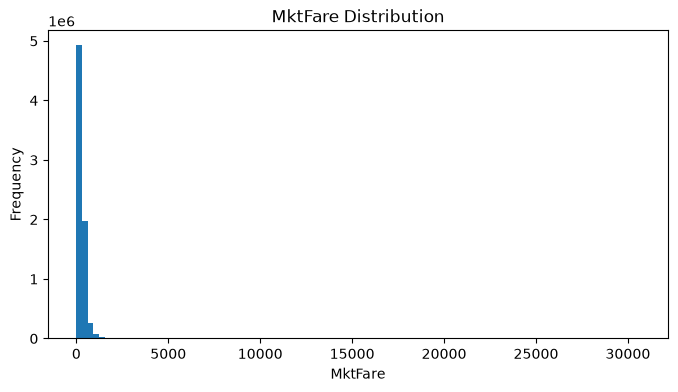

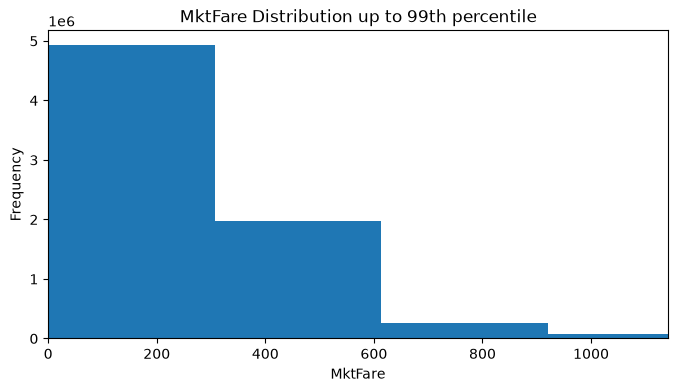

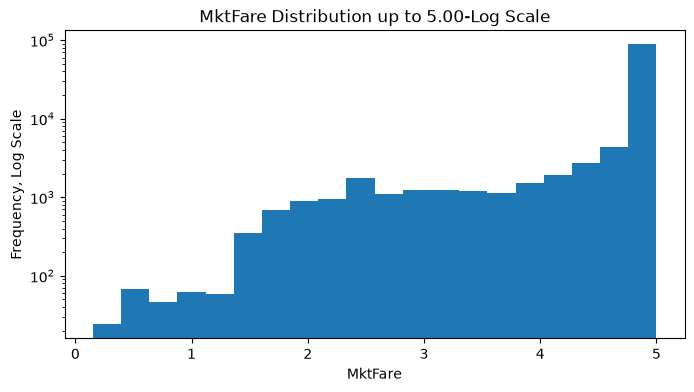

In [208]:
plt.figure(figsize=(8,4))
plt.hist(df["MktFare"], bins=100)
plt.title("MktFare Distribution")
plt.xlabel("MktFare")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df["MktFare"], bins=100)
plt.xlim(0, df['MktFare'].quantile(0.99))
plt.title("MktFare Distribution up to 99th percentile")
plt.xlabel("MktFare")
plt.ylabel("Frequency")
plt.show()

low_mktfare = df[df['MktFare'] <= 5.00]
plt.figure(figsize=(8, 4))
plt.hist(low_mktfare['MktFare'], bins=20)
plt.yscale('log')
plt.title("MktFare Distribution up to 5.00-Log Scale")
plt.xlabel("MktFare")
plt.ylabel("Frequency, Log Scale")
plt.show()


In [ ]:
display(low_mktfare.shape)
display(low_mktfare.sample(10))
df['fare_group'] = df['MktFare'].apply(lambda x: 'Low fare' if x <= 5.00 else 'Normal fare')
display(df.groupby('fare_group').agg({'MktFare': ['count', 'mean', 'median'], 'MktDistance': ['mean', 'median'], 'Passengers': ['mean', 'median']}))

#Low MktFare values (≤ $5) are concentrated at exactly $5.00, occur on long routes, and are mostly MktCoupons = 2. 
# They reflect prorated segment fares and DB1B reporting, not typical standalone ticket prices. 
# Possible exclution in modelling.

(109404, 22)

,ItinID,MktID,MktCoupons,Year,Quarter,OriginCityMarketID,Origin,OriginState,DestCityMarketID,Dest,...,OpCarrierChange,RPCarrier,TkCarrier,OpCarrier,Passengers,MktFare,MktDistance,MktDistanceGroup,NonStopMiles,MktGeoType
6634263,202515663809,20251566380901,1,2025,1,31123,STL,MO,32575,LGB,...,0.00,WN,WN,WN,9.00,5.00,1581.00,4,1581.00,2
1031997,202513009823,20251300982301,1,2025,1,30466,PHX,AZ,30620,BIL,...,0.00,MQ,AA,MQ,2.00,5.00,873.00,2,873.00,2
1719512,202512109363,20251210936301,2,2025,1,31703,LGA,NY,32951,LFT,...,1.00,DL,DL,99,1.00,5.00,1265.00,3,1251.00,2
1213135,202515095492,20251509549201,2,2025,1,31884,GEG,WA,32575,LGB,...,0.00,WN,WN,WN,1.00,5.00,1036.00,3,953.00,2
2647203,202515230990,20251523099001,2,2025,1,33158,MAF,TX,30693,BNA,...,0.00,WN,WN,WN,1.00,4.55,1111.00,3,935.00,2
5351435,202512520392,20251252039201,2,2025,1,33195,TPA,FL,30647,CLE,...,0.00,DL,DL,DL,1.00,5.00,960.00,2,927.00,2
2810597,20251717274,2025171727401,1,2025,1,32467,MIA,FL,31986,GRR,...,0.00,AA,AA,AA,5.00,5.00,1214.00,3,1214.00,2
998517,202512980903,20251298090301,2,2025,1,33198,MCI,MO,34100,PHL,...,1.00,MQ,AA,99,1.00,5.00,1081.00,3,1038.00,2
6322253,202511132947,20251113294701,3,2025,1,33195,TPA,FL,34952,SPI,...,1.00,AA,AA,99,1.00,5.00,1280.00,3,914.00,2
674408,202515729054,20251572905401,3,2025,1,31624,EYW,FL,32457,SJC,...,1.00,YV,UA,99,1.00,5.00,3423.00,7,2520.00,2


MktFare               MktDistance         Passengers       
               count   mean median        mean  median       mean median
fare_group                                                              
Low fare      109404   4.70   5.00     1426.22 1226.00       3.51   1.00
Normal fare  7181124 281.23 237.00     1303.06 1090.00       1.86   1.00

In [ ]:
display(df['MktMilesFlown'].describe())
display(df['MktMilesFlown'].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
display(df[df['MktMilesFlown']== 31][['Origin', 'Dest', 'OriginState', 'DestState', 'MktMilesFlown']])
#31 miles seemed like an outlier but it isnt as upon inspection, it is between towns in Alaska

count   7290528.00
mean       1302.32
std         818.28
min          31.00
25%         725.00
50%        1089.00
75%        1737.00
max       11344.00
Name: MktMilesFlown, dtype: float64

0.01    210.00
0.05    337.00
0.10    446.00
0.25    725.00
0.50   1089.00
0.75   1737.00
0.90   2408.00
0.95   2669.00
0.99   4310.00
Name: MktMilesFlown, dtype: float64

,Origin,Dest,OriginState,DestState,MktMilesFlown
3837495,PSG,WRG,AK,AK,31.00
3837496,PSG,WRG,AK,AK,31.00
3837497,WRG,PSG,AK,AK,31.00
3949463,WRG,PSG,AK,AK,31.00
3949464,WRG,PSG,AK,AK,31.00
3949465,WRG,PSG,AK,AK,31.00
3949466,WRG,PSG,AK,AK,31.00
3949467,PSG,WRG,AK,AK,31.00
3949468,WRG,PSG,AK,AK,31.00
3949469,PSG,WRG,AK,AK,31.00


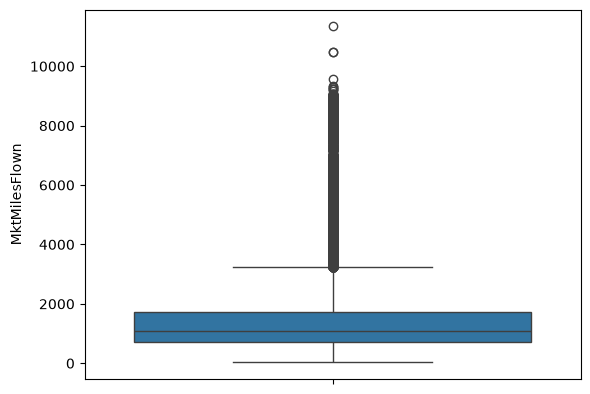

,Origin,Dest,MktFare,MktMilesFlown,MktDistance,MktCoupons
3780077,SLC,GUM,1931.99,10496.00,10496.00,5
3780197,GUM,SEA,2801.00,11344.00,11344.00,5
4261450,STT,GUM,9.00,10464.00,10464.00,4


In [ ]:
sns.boxplot(df['MktMilesFlown'])
plt.show()
df[df['MktMilesFlown']> 10000][['Origin', 'Dest', 'MktFare', 'MktMilesFlown', 'MktDistance', 'MktCoupons']]
#Further explored the extreme outliers in MktMilesFlown, and these are found to be valid values as they are all to GUAM

In [ ]:
miles_q1 = df['MktMilesFlown'].quantile(0.25)
miles_q2 = df['MktMilesFlown'].quantile(0.50)
miles_q3 = df['MktMilesFlown'].quantile(0.75)

print(miles_q1, miles_q2, miles_q3)

miles_iqr = miles_q3 - miles_q1
print(miles_iqr)

miles_lower_bound = miles_q1 - 1.5*miles_iqr
miles_upper_bound = miles_q3 + 1.5*miles_iqr

print(miles_lower_bound, miles_upper_bound)

miles_no_outliers = df[(df['MktMilesFlown'] >= miles_lower_bound) & (df['MktMilesFlown'] <= miles_upper_bound)]
miles_outliers = df[(df['MktMilesFlown'] < miles_lower_bound) | (df['MktMilesFlown'] > miles_upper_bound)]

print(miles_no_outliers.shape)
print(miles_outliers.shape)

#outliers are around 2.37% of the dataset

mile_outliers_df = df[df["MktMilesFlown"] > 3255]

mile_outliers_df[[
    "Origin",
    "Dest",
    "MktGeoType",
    "MktCoupons",
    "MktMilesFlown",
    "NonStopMiles",
    "MktFare"
]].sample(20)
#With this, we can see that the outliers are mainly to non-mainland US(1)

725.0 1089.0 1737.0
1012.0
-793.0 3255.0
(7117691, 24)
(172837, 24)


,Origin,Dest,MktGeoType,MktCoupons,MktMilesFlown,NonStopMiles,MktFare
3840452,RDU,FAI,1,2,3887.00,3406.00,889.00
5666330,MIA,SEA,2,3,3364.00,2724.00,185.00
3394247,OGG,DTW,1,3,4425.00,4417.00,187.00
2133532,MCO,ANC,1,2,4002.00,3818.00,248.50
6250660,SFO,SJU,1,2,3629.00,3630.00,249.62
3778128,HNL,GRR,1,2,4380.00,4360.00,388.50
896090,BIL,LIH,1,2,3852.00,3278.00,354.00
2868696,OGG,ATW,1,3,4673.00,4149.00,255.00
6195604,SAN,SJU,1,2,3552.00,3310.00,303.00
1589706,JFK,KOA,1,2,4979.00,4953.00,5.50


In [ ]:
display(mile_outliers_df["MktGeoType"].value_counts())
#The statement in the previous cell is further backed by this count
mile_outliers_df[mile_outliers_df["MktGeoType"] == 2][[
    'Origin', 'Dest', 'MktMilesFlown', 'MktDistance', 'MktFare', 'MktCoupons']].sample(20)
#mainland US outliers are found to be valid values

MktGeoType
1    165680
2      7157
Name: count, dtype: int64

,Origin,Dest,MktMilesFlown,MktDistance,MktFare,MktCoupons
758848,MCO,PDX,3398.00,3398.00,182.00,2
1630898,LGA,LAX,3438.00,3438.00,454.68,2
3369362,DEN,EWR,3532.00,3532.00,659.00,2
1583550,JFK,LAX,3399.00,3399.00,1299.65,4
6234541,BOS,PDX,3309.00,3309.00,186.91,2
7219390,LAX,CHS,3429.00,3429.00,196.00,2
4768262,DCA,SNA,3307.00,3307.00,540.00,2
3795579,ONT,JFK,3378.00,3378.00,266.50,2
3931525,FLL,SFO,3396.00,3396.00,173.50,2
6240890,SEA,PHL,3737.00,3737.00,5.80,2


In [ ]:
df['BulkFare'].value_counts()
#BulkFare has two values, 0 and 1. 0 shows that the fare is not bulk fare and 1 shows that it is a bulk fare(agency and tour group bookings)
#MktFare was 0 in rows where BulkFare is 1 and this accounted for around 513 rows. These rows were dropped when the filter
#MktFare > 0 was applied to the dataset

BulkFare
0.00    7290528
Name: count, dtype: int64

In [139]:
df[['MktDistance', 'MktMilesFlown', 'NonStopMiles']].describe()
#MktDistance and MktMilesFlown have basically the same values, thus MktMilesFlown is not needed

,MktDistance,MktMilesFlown,NonStopMiles
count,7290528.00,7290528.00,7290528.00
mean,1304.90,1302.32,1226.36
std,819.61,818.28,776.63
min,31.00,31.00,31.00
25%,727.00,725.00,667.00
50%,1091.00,1089.00,1029.00
75%,1739.00,1737.00,1624.00
max,11344.00,11344.00,9411.00


In [155]:
df = df.drop(columns=['MktMilesFlown'])
print(df.columns)

Index(['ItinID', 'MktID', 'MktCoupons', 'Year', 'Quarter',
       'OriginCityMarketID', 'Origin', 'OriginState', 'DestCityMarketID',
       'Dest', 'DestState', 'TkCarrierChange', 'OpCarrierChange', 'RPCarrier',
       'TkCarrier', 'OpCarrier', 'BulkFare', 'Passengers', 'MktFare',
       'MktDistance', 'MktDistanceGroup', 'NonStopMiles', 'MktGeoType'],
      dtype='str')


,count,median,mean
MktDistanceGroup,,,
1,904452,184.00,205.09
2,2235134,209.00,235.67
3,1792351,231.71,265.45
4,1003458,268.50,312.57
5,778027,284.00,350.45
6,364510,289.50,376.95
7,65867,326.00,405.13
8,43306,372.86,488.26
9,43348,413.45,534.29


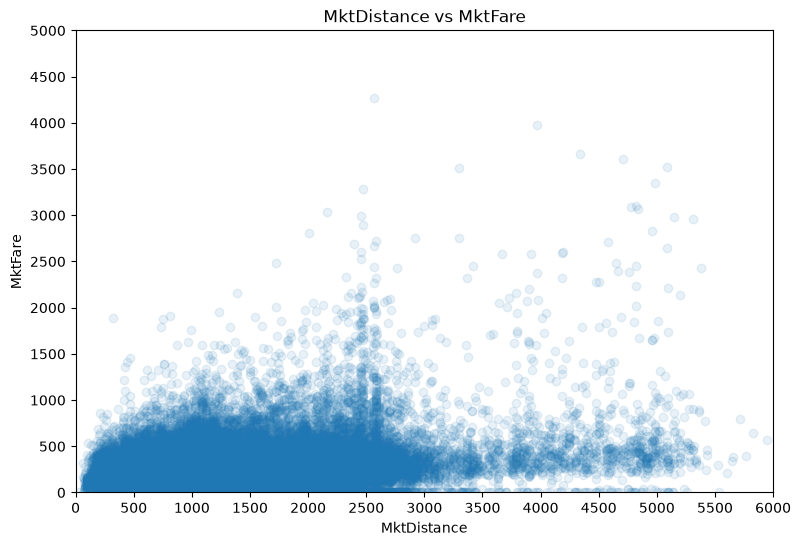

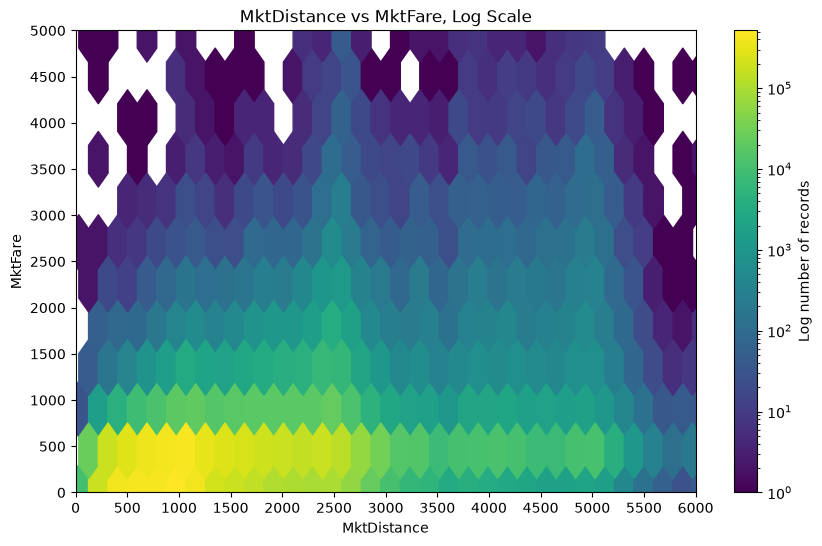

In [ ]:
display(df.groupby('MktDistanceGroup')['MktFare'].agg(['count', 'median', 'mean']))

distanceVSfare = df.sample(50000, random_state=42)
plt.figure(figsize=(9, 6))
plt.scatter(distanceVSfare['MktDistance'], distanceVSfare['MktFare'], alpha=0.1)
plt.xlim(0, 6000)
plt.ylim(0, 5000)
plt.xticks(np.arange(0, 6001, 500))
plt.yticks(np.arange(0, 5001, 500))
plt.title('MktDistance vs MktFare')
plt.xlabel('MktDistance')
plt.ylabel('MktFare')
plt.show()
#scatterplots are not able to show much as the data is too dense

plt.figure(figsize=(10,6))
plt.hexbin(df['MktDistance'], df['MktFare'], gridsize=60, mincnt=1, bins='log')
plt.colorbar(label='Log number of records')
plt.xlabel('MktDistance')
plt.ylabel('MktFare')
plt.title('MktDistance vs MktFare, Log Scale')
plt.xlim(0, 6000)
plt.ylim(0, 5000)
plt.xticks(np.arange(0, 6001, 500))
plt.yticks(np.arange(0, 5001, 500))
plt.show()
#hexbin to show relation between distance and fare, however the relation is not really linear, with some signs that
#the upper range of fares seems to increase with distance to a certain extent

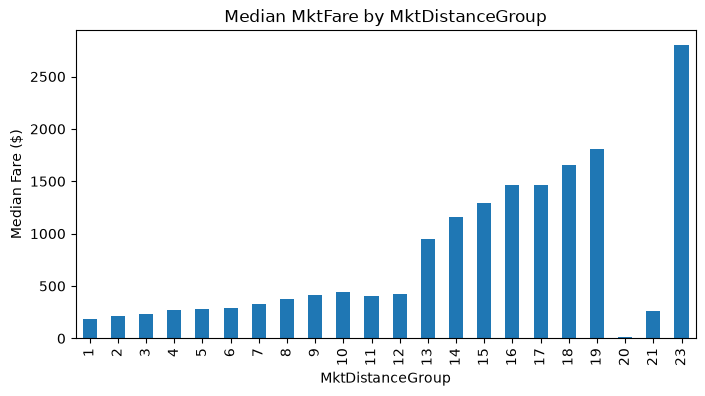

MktDistanceGroup
1      904452
2     2235134
3     1792351
4     1003458
5      778027
6      364510
7       65867
8       43306
9       43348
10      39733
11      17391
12        927
13        566
14        389
15        119
16        236
17        275
18        408
19         26
20          1
21          3
23          1
Name: count, dtype: int64

In [ ]:
df.groupby('MktDistanceGroup')['MktFare'].median().plot(kind='bar', figsize=(8, 4))
plt.title('Median MktFare by MktDistanceGroup')
plt.ylabel('Median Fare ($)')
plt.show()
#the trend is more visible when using MktDistanceGroup, with median fare increasing with distance group

df["MktDistanceGroup"].value_counts().sort_index()
# this explains why the median in group 20, 21 and 23 are unusual

count   7290528.00
mean          1.89
std           4.86
min           1.00
25%           1.00
50%           1.00
75%           1.00
max        1032.00
Name: Passengers, dtype: float64

Passengers
1.00      5634104
2.00       763375
3.00       303873
4.00       164768
5.00       101486
           ...   
250.00          1
373.00          1
289.00          1
223.00          1
243.00          1
Name: count, Length: 359, dtype: int64


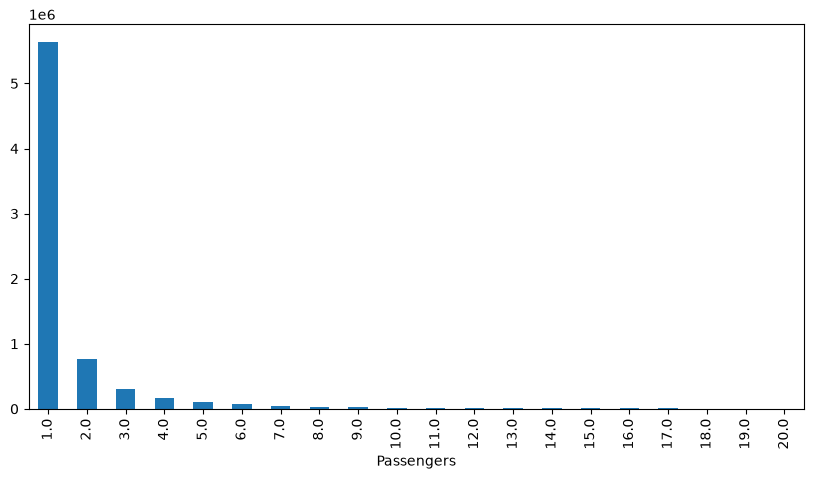

In [161]:
display(df['Passengers'].describe())

passenger_counts = df['Passengers'].value_counts()
print(passenger_counts)
passenger_counts.head(20).plot(kind='bar', figsize=(10, 5))
plt.show()


In [162]:
df[df['Passengers'] >= 100][['Origin', 'Dest', 'Passengers', 'MktFare', 'MktDistance', 'MktCoupons']].sample(20)

,Origin,Dest,Passengers,MktFare,MktDistance,MktCoupons
3112364,FAI,ANC,113.00,6.00,261.00,1
6491145,LAX,EWR,110.00,403.00,2454.00,1
7186011,HPN,PBI,101.00,268.00,1056.00,1
3889270,MCO,SEA,127.00,68.50,2554.00,1
4845532,OAK,LAX,208.00,269.00,337.00,1
4688795,MKE,MCO,115.00,5.50,1066.00,1
2086064,PHX,CLT,107.00,5.50,1773.00,1
820469,LIH,HNL,118.00,74.50,102.00,1
1451328,DFW,SAN,112.00,5.00,1171.00,1
3172675,MSP,DFW,100.00,161.00,852.00,1


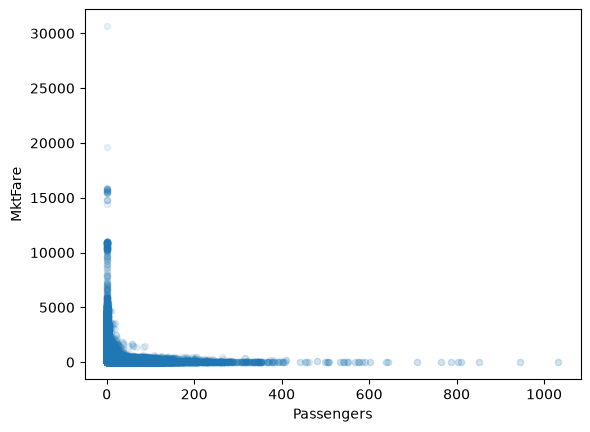

np.float64(62.28215767634855)

In [ ]:
df.plot.scatter(x='Passengers', y='MktFare', alpha=0.1)
plt.show()
#from this scatter plot, we can see that lower passenger count has a higher fare and higher passenger count has a lower fare

display((df[df['Passengers'] >= 100]['MktFare'] <= 5.50).mean()*100)
#this shows the percentage of fares that are <= 5.50 for passenger values >= 100

In [ ]:
display(df['MktCoupons'].value_counts())
display(df['MktCoupons'].describe())
df.groupby('MktCoupons')['MktFare'].median()
display((df['MktFare'] <= 5.5).groupby(df['MktCoupons']).mean() * 100)
#This command show the percentage of rows that has mktfare <= 5.5 for each mktcoupons value

MktCoupons
1    4221659
2    2908700
3     152138
4       7414
5        558
6         54
7          4
8          1
Name: count, dtype: int64

count   7290528.00
mean          1.44
std           0.54
min           1.00
25%           1.00
50%           1.00
75%           2.00
max           8.00
Name: MktCoupons, dtype: float64

MktCoupons
1   2.18
2   6.16
3   4.83
4   1.59
5   0.72
6   0.00
7   0.00
8   0.00
Name: MktFare, dtype: float64

In [195]:
display((df['TkCarrier'] != df['OpCarrier']).mean())
display((df['RPCarrier'] != df['TkCarrier']).mean())
#these show the percentages of rows where the tkcarrier and opcarrier are different
display(df.groupby(df['TkCarrier'] != df['OpCarrier'])['MktFare'].median())



np.float64(0.26629456741679064)

np.float64(0.2284595848201941)

False   226.00
True    256.65
Name: MktFare, dtype: float64

In [191]:
df = df.drop(columns=['BulkFare'])
print(df.columns)

Index(['ItinID', 'MktID', 'MktCoupons', 'Year', 'Quarter',
       'OriginCityMarketID', 'Origin', 'OriginState', 'DestCityMarketID',
       'Dest', 'DestState', 'TkCarrierChange', 'OpCarrierChange', 'RPCarrier',
       'TkCarrier', 'OpCarrier', 'Passengers', 'MktFare', 'MktDistance',
       'MktDistanceGroup', 'NonStopMiles', 'MktGeoType'],
      dtype='str')


In [196]:
(df['MktDistance']-df['NonStopMiles']).describe()

count   7290528.00
mean         78.54
std         172.87
min          -1.00
25%           0.00
50%           0.00
75%          68.00
max        6458.00
dtype: float64

In [197]:
df['MktFare'].describe()

count   7290528.00
mean        277.08
std         232.81
min           0.15
25%         150.00
50%         234.00
75%         348.00
max       30656.00
Name: MktFare, dtype: float64

Multiple columns have been dropped during this data exploration process, namely ['OriginCountry', 'DestCountry', 'OriginAirportSeqID', 'DestAirportSeqID', 'OriginStateName',
 'DestStateName', 'OriginStateFips', 'OriginWac', 'DestStateFips', 'DestWac', 'WacGroup', 'Unnamed: 41', 'AirportGroup', 'ItinGeoType', 'OriginAirportID', 
 'DestAirportID', 'OpCarrierGroup', 'TkCarrierGroup', 'BulkFare', 'MktMilesFlown']

MktDistance outliers are valid ones as they are all cross country flights or non-mainland US flights to places like Alaska, Hawaii etc. These values will be kept as they are still valid domestic entries.

MktFare had invalid values under 0 which has been removed. Upon exploration, the Fare of 5.50 is the most common and there are more than 200k rows that has a fare value of <= 5.50. Out of these, 92k reside in the marketing coupon value of 1 and around 179k in the value of 2. Group 1 might be due to special fares like mile redemptions. Group 2 and more are highly likely to be prorated values based on segments. Do note that for values lower than the 0.01 quantile(5.00), they are concentrated at exactly $5.00, occur on long routes, and are mostly MktCoupons = 2. They reflect prorated segment fares and DB1B reporting, not typical standalone ticket prices. These lower fares might be excluded from modelling. 

Most rows are densly concentrated around the 500 miles to a fare of 500 range, with not much of a relationship formed between distance and fare. However, if we put the median of distance groups/bins against fares, there is a linear trend to be notice with the exception of groups 20-23 due to low counts.

